# Assignment 4 Problem II: Helmholtz Steepest Descent #

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import dolfin as dl
import ufl
from hippylib import nb

import numpy as np
import logging


logging.getLogger('FFC').setLevel(logging.WARNING)
logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

np.random.seed(seed=42)

\begin{gather*}
  m(x,y) = \begin{cases}
    0.2 & \text{if} \; \sqrt{(x - 0.1)^2 + 2 (y + 0.2)^2} < 0.5 \\
    0 & \text{otherwise} \\
  \end{cases} \\
\end{gather*}


Refinement level 0; Number of mesh elements: 6402


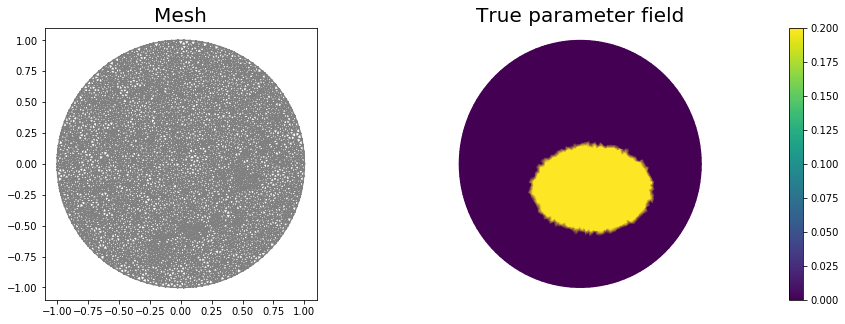

In [2]:
# create mesh and define function spaces
# mesh = dl.RectangleMesh(dl.Point(-1,-1),dl.Point(1,1), 32, 32)
mesh = dl.Mesh("circle.xml")
print("Refinement level 0; Number of mesh elements: {0}".format(mesh.num_cells()))

nrefinements = 0
for i in range(nrefinements):
    mesh = dl.refine(mesh)
    print("Refinement level {0}; Number of mesh elements: {1}".format(i+1, mesh.num_cells()))

Vm = dl.FunctionSpace(mesh, 'Lagrange', 1)
Vu = dl.FunctionSpace(mesh, 'Lagrange', 2)

# The true parameter, continuous and discretized/interpolated.
mtrue_cont = dl.Expression('0. + 0.2 * ((pow(x[0] - 0.1, 2) + 2*pow(x[1] + 0.2, 2)) < pow(0.5,2))', degree=5)
mtrue = dl.interpolate(mtrue_cont, Vm)

# plot
plt.figure(figsize=(15,5))
nb.plot(mesh, subplot_loc=121, mytitle="Mesh", show_axis='on')
nb.plot(mtrue, subplot_loc=122, mytitle="True parameter field")
plt.show()

The computational domain $\Omega = \{ x \in \mathbb{R}^2 \; | \; {\lVert x \rVert}^2 < 1 \}$ is the unit disc, $k_0 = 5$ is the wave number, and $\beta > 0$ is the regularization parameter. The incident wavefield $u^{\text{inc}}(x)$ is the superposition of three spherical waves with wave number $k_0$ generated by point-like sources. That is:

\begin{gather*}
  u^{\text{inc}}(x) = \sum\limits_{j=1}^{3} -e_i \frac{\cos (k_0 {\lvert x - x_i \rvert})}{4 \pi {\lvert x - x_i \rvert}} \\
\end{gather*}

where $x_i$ denote the locations of the three point-like sources and $e_i \sim N(0,1)$ are randomly chosen coefficients.

We will actually define $u_i$ for $\{1,2,3\}$ first, then multiply by the random number and combine in the next step.


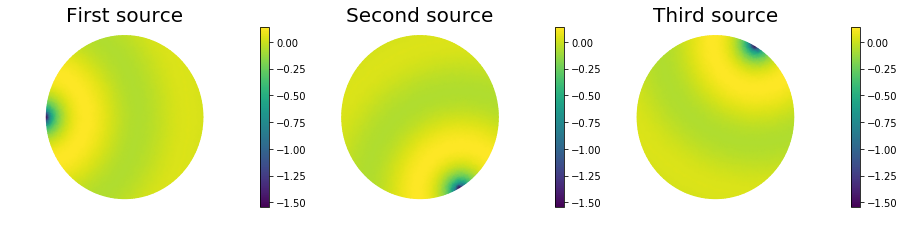

In [3]:
k0raw = 5.
k0sq = dl.Constant(k0raw*k0raw)
nsources = 3

def build_inc_wave(i):
    theta = -np.pi + 2*np.pi*i/nsources
    radius = 1.05
    xi = [radius*np.cos(theta), radius*np.sin(theta)]
    
    ei = np.random.normal()
    
    distance_source = dl.Expression("std::sqrt((x[0]-s0)*(x[0]-s0) + (x[1]-s1)*(x[1]-s1))",
                                    s0=xi[0], s1=xi[1], degree=1)
    u_i_exp = dl.Expression("-std::cos(k0*distance_source)/(4.*DOLFIN_PI*distance_source)",
                              k0=k0raw, distance_source=distance_source, degree=6)
    return dl.interpolate(u_i_exp, Vu)

# build_inc_wave(1)
u_is = [build_inc_wave(i) for i in range(nsources)]

# plot
plt.figure(figsize=(15,3.3))
nb.plot(u_is[0], subplot_loc=131, mytitle="First source")
nb.plot(u_is[1], subplot_loc=132, mytitle="Second source")
nb.plot(u_is[2], subplot_loc=133, mytitle="Third source")
plt.show()

## Source encoding

Source encoding is a common technique based on superposition of effects to reduce the computational cost of full-waveform inversion.

Simply put, source encoding exploits the linearity of the Helmholtz equation with respect to the source term and computes a single pressure field correspoding to the simulataneous exitation of all sources together. Here, we take the superimposed source $u_inc$ to be a random linear combination of all sources $u_i$. The weights $e_i$ of this linear combination are sampled from a i.i.d. Gaussian distribution. That is:

$$ u_{inc}(\boldsymbol{x}) = \sum_i e_i u_i(\boldsymbol{x}), \quad e_i \sim \mathcal{N}(0,1). $$

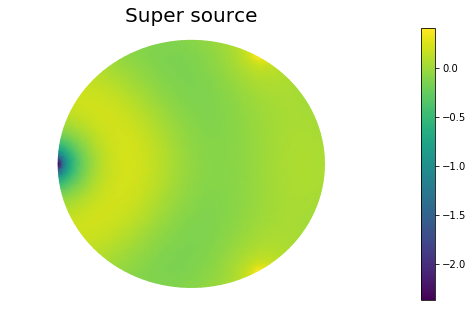

In [4]:
encoding = np.random.normal(size=nsources)

u_inc = dl.Function(Vu)

for i, u_i in enumerate(u_is):
    u_inc.vector().axpy(encoding[i], u_i.vector())
    
plt.figure(figsize=(7.5,5))
nb.plot(u_inc, mytitle="Super source")
plt.show()

In [5]:
# define trial/test/regular functions for parameter, state and adjoint
m, m_trial, m_test = dl.Function(Vm), dl.TrialFunction(Vm), dl.TestFunction(Vm)
u, u_trial, u_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)
p, p_trial, p_test = dl.Function(Vu), dl.TrialFunction(Vu), dl.TestFunction(Vu)


The forward equation is the Helmholtz equation:

\begin{gather*}
  - \Delta u - k_0^2 (1 - \tanh(m)) u = k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}}, \quad \text{in} \; \Omega \\
  \frac{\partial u}{\partial n} = 0, \quad \text{on} \; \Gamma \\
\end{gather*}


in weak form:

\begin{gather*}
%  - \int_\Omega \Delta u p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^\text{inc} p \; d\vec{x} \\
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


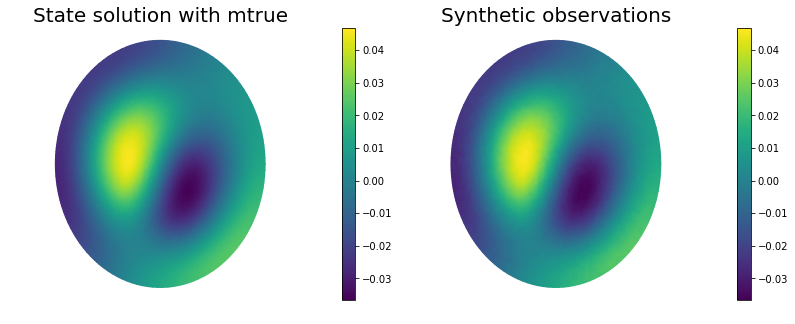

In [6]:
# noise level
noise_level = 0.01

forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(mtrue)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(mtrue) * u_inc * u_test * ufl.dx

# solve the forward/state problem to generate synthetic observations
bc_state = []
forward_lhsa, forward_rhsa = dl.assemble_system(ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)

utrue = dl.Function(Vu)
dl.solve(forward_lhsa, utrue.vector(), forward_rhsa)
assert np.all(np.isfinite(utrue.vector().get_local())), "State solution contains NaNs"


d = dl.Function(Vu)
d.assign(utrue)

# perturb state solution and create synthetic measurements d
# d = u + ||u||/SNR * random.normal
MAX = d.vector().norm("linf")
noise = dl.Vector()
forward_lhsa.init_vector(noise,1)
noise.set_local( noise_level * MAX * np.random.normal(0, 1, len(d.vector().get_local())) )

d.vector().axpy(1., noise)

# plot
nb.multi1_plot([utrue, d], ["State solution with mtrue", "Synthetic observations"])
plt.show()

Our cost function is as follows:

\begin{gather*}
  \min\limits_{m} \Phi (m) := \frac{1}{2}
  \int_\Gamma (u(m) - d)^2 \; ds
  + \frac{\beta}{2} \int_\Omega {\lVert \nabla m \rVert}^2 \; d\vec{x} \\
\end{gather*}


In [7]:
# Regularization parameter
gamma = 1e-5
beta = gamma

# Define cost function
def cost(u, d, m, gamma):
    misfit = 0.5 * dl.assemble( (u-d)**2*ufl.ds)
    reg = 0.5*gamma * dl.assemble( ufl.inner(dl.grad(m), ufl.grad(m))*ufl.dx ) 
    return [misfit + reg, misfit, reg]

Our forward equation in weak form. We covered this earlier, but we are redefining with $m$ instead of $m_{\text{true}}$

\begin{gather*}
  \int_\Omega \nabla u \nabla p \; d\vec{x} - \int_\Omega k_0^2 (1 - \tanh(m)) u p \; d\vec{x} = \int_\Omega k_0^2 \cdot \tanh(m) \cdot u^{\text{inc}} p \; d\vec{x}, \quad \forall p \in \mathcal{U} \\
\end{gather*}


In [8]:
# We defined this earlier, but now we define with variable m, not m_true.
# Given m, solve for u.
forward_eq = ufl.inner(ufl.grad(u_trial), ufl.grad(u_test)) * ufl.dx \
        - k0sq * (dl.Constant(1.) - ufl.tanh(m)) * u_trial * u_test * ufl.dx \
        - k0sq * ufl.tanh(m) * u_inc * u_test * ufl.dx

# set up dirichlet boundary conditions
def boundary(x,on_boundary):
    return on_boundary

bc_state = [] # dl.DirichletBC(Vu, dl.Constant(0.), boundary)

The first variation of the Lagrangian with respect to $u$ gives us the weak form of the adjoint equation:

\begin{gather*}
  \mathcal{L}_u(u,m,p; \tilde{u}) :=
  \int_\Gamma (u - d) \tilde{u} \; d\vec{s}
  + \int_\Omega \nabla \tilde{u} \nabla p
  - k_0^2 (1 - \tanh(m)) \tilde{u} p
  \; d\vec{x}, \quad \forall \tilde{u} \in \mathcal{V} \\
\end{gather*}

In [9]:
# Given m, u, solve for adjoint p
# adjoint_eq = ufl.inner(u-d, p_test) * ufl.ds \
#     + ufl.inner(ufl.grad(p_test), ufl.grad(p_trial)) * ufl.dx \
#     - k0sq * (1. - ufl.tanh(m)) * p_test * p_trial * ufl.dx
adjoint_eq = (u - d) * p_test * ufl.ds \
   + ufl.inner(ufl.grad(p_trial), ufl.grad(p_test)) * ufl.dx \
   - k0sq * (1. - ufl.tanh(m)) * p_trial * p_test * ufl.dx


bc_adj = [] # The first term is the boundary condition.

The first variation of the Lagrangian with respect to $m$ gives us the weak form of the gradient of the objective when we use the corresponding $u,p$ from the state equation and adjoint equation:

\begin{gather*}
  \mathcal{L}_m(u,m,p; \tilde{m}) :=
  \int_\Omega \beta \nabla m \nabla \tilde{m} \; d\vec{x}
  + \int_\Omega k_0^2 \cdot \tilde{m} / \cosh^2(m) \cdot (u p - u^{\text{inc}} p) \; d\vec{x}
  , \quad \forall \tilde{m} \in \mathcal{M} \\
\end{gather*}

In [10]:
# Given m, u, p, solve for adjoint p
grad_reg = dl.Constant(gamma) * ufl.inner(ufl.grad(m), ufl.grad(m_test)) * ufl.dx
grad_misfit = k0sq * m_test / (ufl.cosh(m) * ufl.cosh(m)) * (u * p - u_inc * p) * ufl.dx


### Finite difference check of the gradient

We use a **finite difference check** to verify that our gradient derivation is correct.
Specifically, we consider a function $ m_0\in \mathcal{M}$ and we verify that for an arbitrary direction $\tilde{m} \in \mathcal{M}$ we have
$$ r := \left| \frac{ \mathcal{J}(m_0 + \varepsilon \tilde{m}) - \mathcal{J}(m_0)}{\varepsilon} -  \left(\mathcal{G}(m_0), \tilde{m}\right)\right| = \mathcal{O}(\varepsilon).$$

In the figure below we show in a loglog scale the value of $r$ as a function of $\varepsilon$. We observe that $r$ decays linearly for a wide range of values of $\varepsilon$, however we notice an increase in the error for extremely small values of $\varepsilon$ due to numerical stability and finite precision arithmetic.


State norm: 0.0
c0=0.0010527675252309317
Adjoint norm: 1.2431027232062508
grad0 norm: 0.002366969441128815


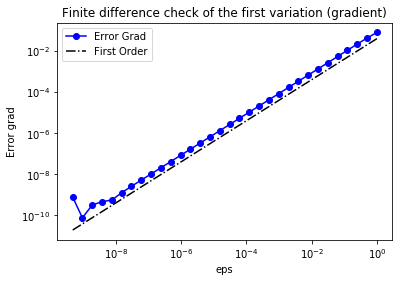

In [11]:
# Poisson m0
# m0 = dl.interpolate(dl.Constant(np.log(4.) ), Vm )
# Helmholtz m0
m0 = dl.interpolate(dl.Constant( 0. ), Vm )

n_eps = 32
eps = np.power(2., -np.arange(n_eps))
err_grad = np.zeros(n_eps)

m.assign(m0)

# Solve the fwd problem and evaluate the cost functional
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
print("State norm:", u.vector().norm("l2"))    

c0, _, _ = cost(u, d, m, gamma)
print(f"c0={c0}")

# Solve the adjoint problem and evaluate the gradient
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"
print("Adjoint norm:", p.vector().norm("l2"))    

# evaluate the gradient
grad0 = dl.assemble(grad_misfit + grad_reg)
print("grad0 norm:", grad0.norm("l2"))    

# Define an arbitrary direction m_hat to perform the check 
mtilde = dl.Function(Vm).vector()
mtilde.set_local(np.random.randn(Vm.dim()))
mtilde.apply("")
mtilde_grad0 = grad0.inner(mtilde)

for i in range(n_eps):
    m.assign(m0)
    m.vector().axpy(eps[i], mtilde)
    
    A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
    dl.solve(A, u.vector(), state_b)
    assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"
#     print("State norm:", u.vector().norm("l2"))

    cplus, _, _ = cost(u, d, m, gamma)
   
    err_grad[i] = abs( (cplus - c0)/eps[i] - mtilde_grad0 )

plt.figure()    
plt.loglog(eps, err_grad, "-ob", label="Error Grad")
plt.loglog(eps, (.5*err_grad[0]/eps[0])*eps, "-.k", label="First Order")
plt.title("Finite difference check of the first variation (gradient)")
plt.xlabel("eps")
plt.ylabel("Error grad")
plt.legend(loc = "upper left")
plt.show()

### Initial guess

We solve the state equation and compute the cost functional for the initial guess of the parameter ``m0``

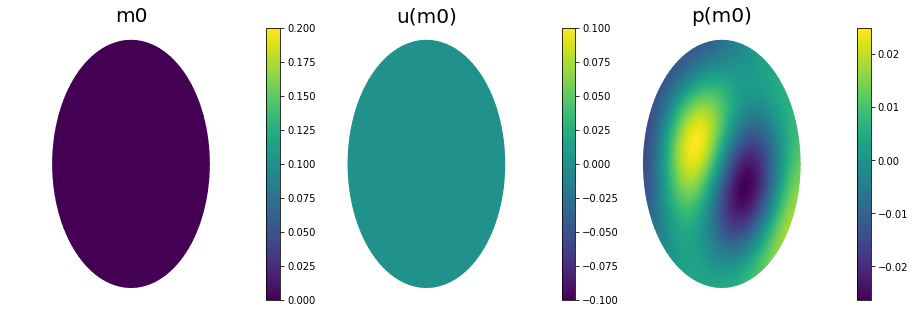

In [12]:
m.assign(m0)

# solve state equation
A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
dl.solve(A, u.vector(), state_b)
assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

# solve the adoint problem
adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
dl.solve(adj_A, p.vector(), adjoint_RHS)
assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"


# evaluate cost
[cost_old, misfit_old, reg_old] = cost(u, d, m, gamma)

# plot
plt.figure(figsize=(15,5))
nb.plot(m, subplot_loc=131, mytitle="m0", vmin=mtrue.vector().min(), vmax=mtrue.vector().max())
nb.plot(u, subplot_loc=132, mytitle="u(m0)")
nb.plot(p, subplot_loc=133, mytitle="p(m0)")
plt.show()

## The steepest descent with Armijo line search:

We solve the constrained optimization problem using the steepest descent method with Armijo line search.

The stopping criterion is based on a relative reduction of the norm of the gradient (i.e. $\frac{\|g_{n}\|}{\|g_{0}\|} \leq \tau$).

The gradient is computed by solving the state and adjoint equation for the current parameter $m$, and then substituing the current state $u$, parameter $m$ and adjoint $p$ variables in the weak form expression of the gradient:

$$ (g, \tilde{m}) = \gamma(\nabla m, \nabla \tilde{m}) +(\tilde{m}e^m\nabla u, \nabla p).$$

Note that to obtain the expansion coefficient of the gradient $g$ in the finite element basis, we need to solve a linear system, where the left-hand side matrix is a mass matrix (stemming from finite element discretization of the $L^2$-inner product. In practice, we can also precondition the gradient descent direction by use of any symmetric positive definite operator $P$. For example, we can take $P$ as the finite element matrix stemming from discretization of the $H^1$-inner product.

The Armijo line search uses backtracking to find $\alpha$ such that a sufficient reduction in the cost functional is achieved.
Specifically, we use backtracking to find $\alpha$ such that:

$$J( m - \alpha g ) \leq J(m) - \alpha c_{\rm armijo} (g,g). $$


In [13]:
# Mass matrix in parameter space
Mvarf    = ufl.inner(m_trial, m_test) * ufl.dx
M = dl.assemble(Mvarf)

#  matrix in parameter space
Kvarf    = ufl.inner(m_trial, m_test) * ufl.dx + ufl.inner(ufl.grad(m_trial), ufl.grad(m_test)) * ufl.dx
K = dl.assemble(Kvarf)

Nit  cost          misfit        reg         ||grad||       alpha  N backtrack
  0   7.30072e-04   7.29998e-04   7.41672e-08   7.75537e-02   1.25000e-01     3


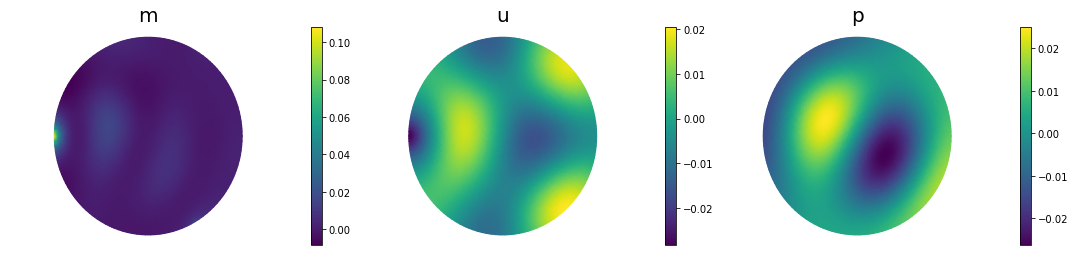

 10   9.45918e-05   9.42724e-05   3.19387e-07   2.50819e-02   1.12627e-01     1
 20   4.71068e-05   4.66943e-05   4.12495e-07   6.50531e-03   2.02958e-01     0
 30   3.04110e-05   2.99562e-05   4.54821e-07   4.56094e-03   1.82868e-01     0
 40   2.18224e-05   2.13393e-05   4.83007e-07   3.28532e-03   1.64767e-01     0
 50   1.63650e-05   1.58546e-05   5.10479e-07   3.03602e-03   1.48458e-01     1


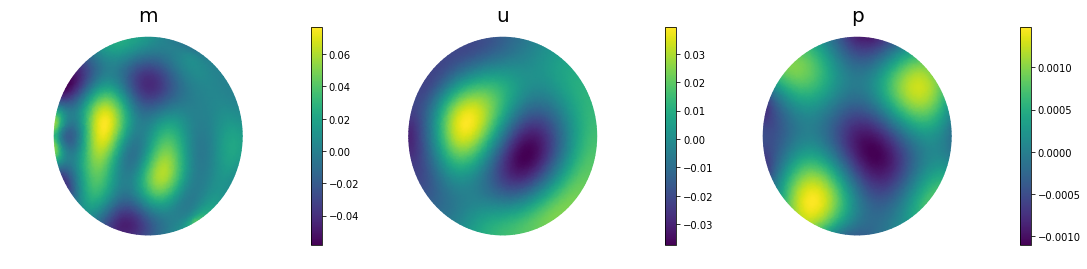

 60   1.25483e-05   1.20137e-05   5.34679e-07   1.91603e-03   1.33763e-01     0
 70   9.86715e-06   9.30862e-06   5.58529e-07   1.45442e-03   1.20523e-01     0
 80   8.00611e-06   7.42315e-06   5.82959e-07   1.57275e-03   2.17186e-01     0
 90   6.46859e-06   5.86648e-06   6.02107e-07   2.22725e-03   9.78439e-02     1
100   5.55018e-06   4.93111e-06   6.19066e-07   1.25051e-03   1.76318e-01     0


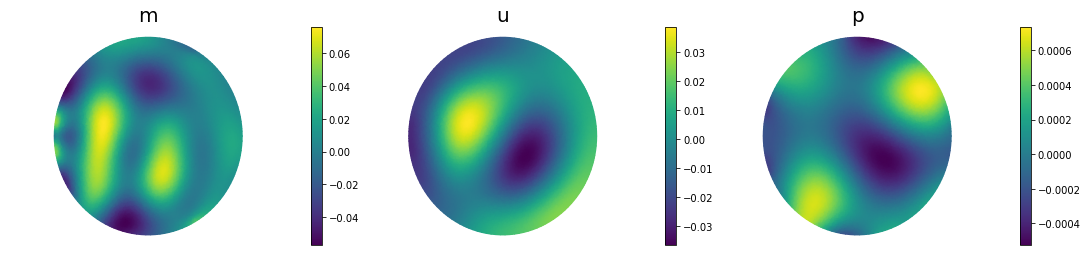

110   4.81022e-06   4.17684e-06   6.33381e-07   1.12273e-03   1.58865e-01     0
120   4.32144e-06   3.67505e-06   6.46388e-07   1.74683e-03   1.43140e-01     1
130   3.83198e-06   3.17461e-06   6.57375e-07   1.31368e-03   1.28972e-01     1
140   3.45411e-06   2.78640e-06   6.67712e-07   9.07376e-04   1.16205e-01     1
150   3.17560e-06   2.49866e-06   6.76947e-07   1.14387e-03   1.04703e-01     2


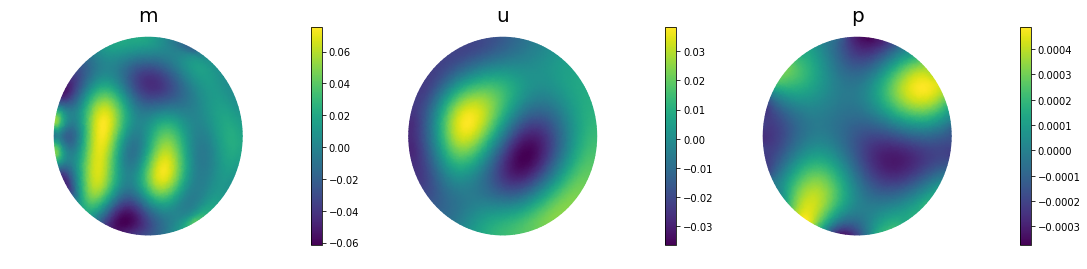

160   2.97985e-06   2.29553e-06   6.84320e-07   5.62707e-04   1.88678e-01     0
170   2.80809e-06   2.11754e-06   6.90547e-07   4.67450e-04   1.70002e-01     0
180   2.67065e-06   1.97438e-06   6.96271e-07   5.08361e-04   1.53175e-01     1
190   2.55209e-06   1.85094e-06   7.01158e-07   3.58155e-04   1.38013e-01     0
200   2.45653e-06   1.75094e-06   7.05595e-07   4.15549e-04   1.24352e-01     1


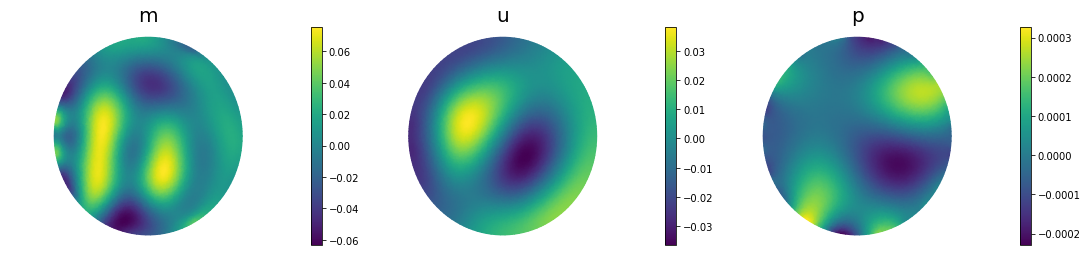

210   2.38016e-06   1.67048e-06   7.09681e-07   3.36888e-04   2.24086e-01     0
220   2.29922e-06   1.58592e-06   7.13299e-07   2.47025e-04   2.01905e-01     0
230   2.24023e-06   1.52396e-06   7.16273e-07   4.14530e-04   9.09599e-02     1
240   2.19239e-06   1.47314e-06   7.19242e-07   3.93775e-04   1.63913e-01     1
250   2.14208e-06   1.42045e-06   7.21625e-07   2.57999e-04   1.47688e-01     0


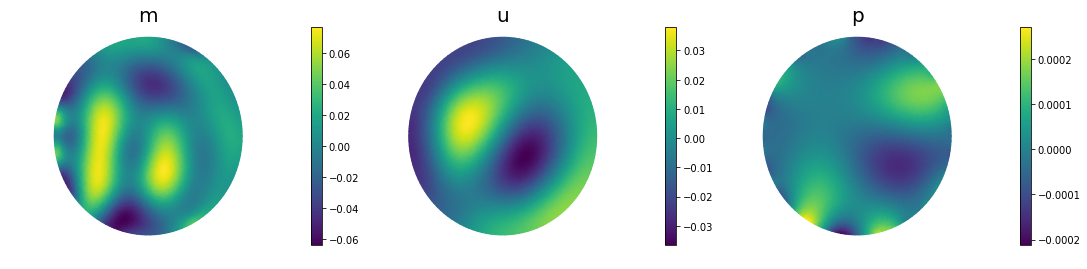

260   2.10309e-06   1.37926e-06   7.23836e-07   3.25742e-04   1.33069e-01     1
270   2.06436e-06   1.33836e-06   7.26003e-07   3.59881e-04   1.19898e-01     1
280   2.03320e-06   1.30539e-06   7.27806e-07   4.80785e-04   1.08030e-01     1
290   2.00340e-06   1.27400e-06   7.29397e-07   2.94558e-04   9.73365e-02     1
300   1.97999e-06   1.24897e-06   7.31023e-07   2.74740e-04   1.75404e-01     0


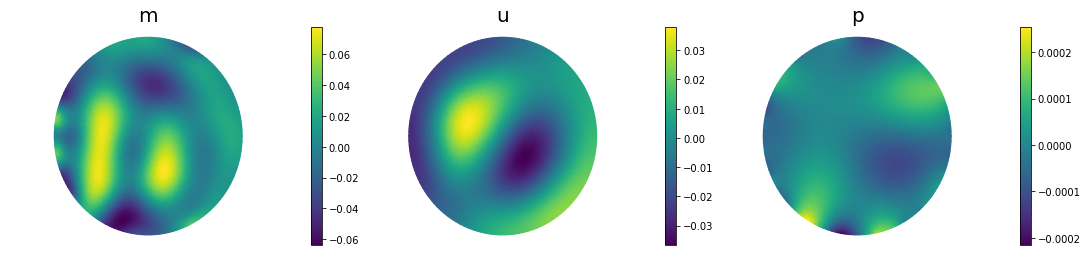

310   1.95378e-06   1.22145e-06   7.32331e-07   1.97969e-04   1.58041e-01     0
320   1.93095e-06   1.19735e-06   7.33602e-07   1.67670e-04   1.42398e-01     1
330   1.91105e-06   1.17625e-06   7.34808e-07   2.59894e-04   1.28303e-01     1
340   1.89164e-06   1.15576e-06   7.35881e-07   2.36857e-04   1.15603e-01     1
350   1.87443e-06   1.13752e-06   7.36910e-07   1.48548e-04   2.08320e-01     0


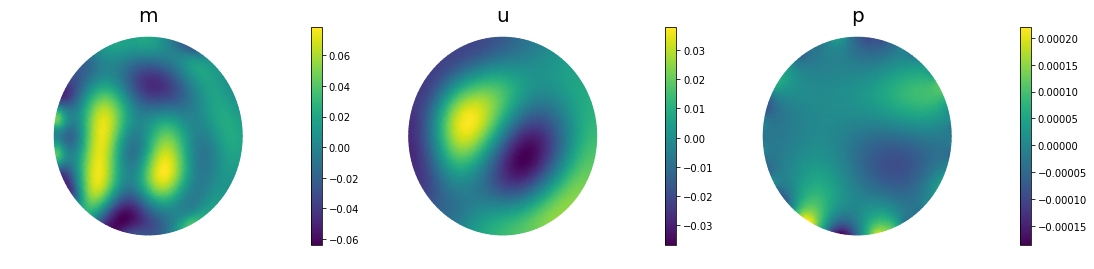

360   1.85687e-06   1.11903e-06   7.37832e-07   1.17389e-04   1.87700e-01     0
370   1.84139e-06   1.10267e-06   7.38724e-07   1.39478e-04   1.69121e-01     0
380   1.82741e-06   1.08791e-06   7.39501e-07   1.54627e-04   1.52381e-01     0
390   1.81394e-06   1.07374e-06   7.40203e-07   1.15383e-04   1.37297e-01     0
400   1.80188e-06   1.06093e-06   7.40947e-07   2.88293e-04   1.23707e-01     1


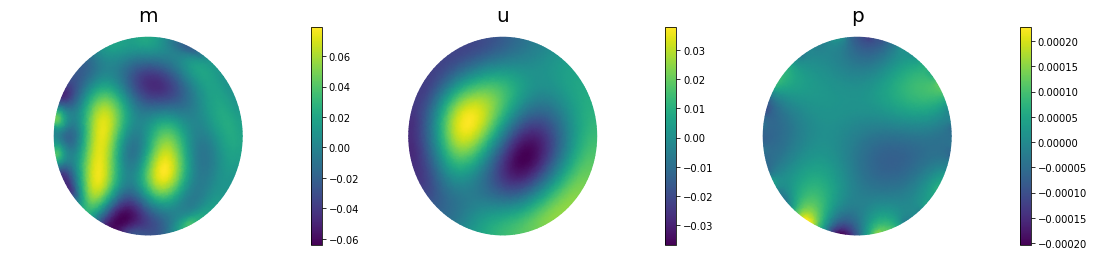

410   1.78877e-06   1.04721e-06   7.41563e-07   1.62631e-04   1.11462e-01     1
420   1.77735e-06   1.03518e-06   7.42165e-07   1.96386e-04   1.00429e-01     1
430   1.76554e-06   1.02277e-06   7.42771e-07   9.18788e-05   1.80977e-01     0
440   1.75377e-06   1.01039e-06   7.43375e-07   2.49083e-04   8.15314e-02     2
450   1.74332e-06   9.99408e-07   7.43909e-07   9.99441e-05   1.46922e-01     0


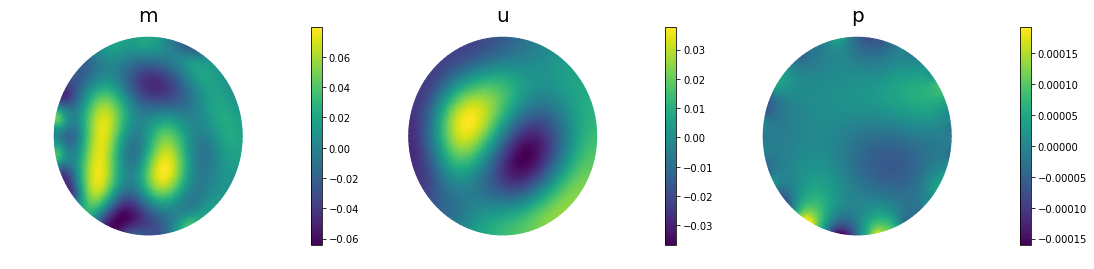

460   1.73417e-06   9.89745e-07   7.44429e-07   2.20918e-04   1.32379e-01     1
470   1.72435e-06   9.79497e-07   7.44858e-07   1.43191e-04   1.19276e-01     1
480   1.71553e-06   9.70199e-07   7.45332e-07   1.13675e-04   2.14939e-01     0
490   1.70634e-06   9.60619e-07   7.45723e-07   1.65273e-04   9.68318e-02     1
500   1.69846e-06   9.52311e-07   7.46149e-07   1.36757e-04   1.74494e-01     0


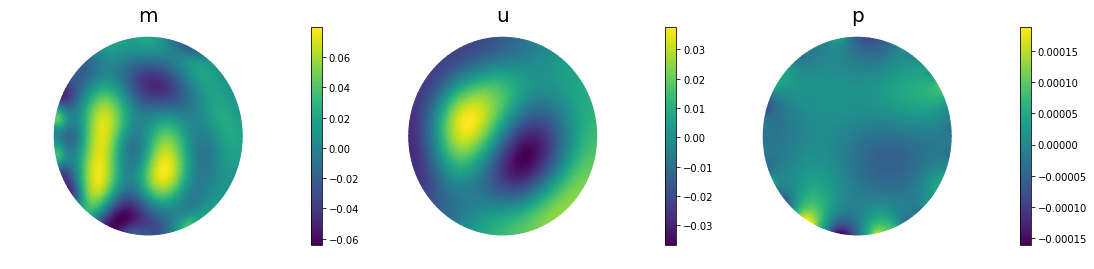

510   1.68941e-06   9.42867e-07   7.46548e-07   1.22693e-04   1.57222e-01     0
520   1.68169e-06   9.34742e-07   7.46946e-07   9.58216e-05   2.83319e-01     0
530   1.67358e-06   9.26313e-07   7.47266e-07   1.26079e-04   1.27638e-01     1
540   1.66641e-06   9.18817e-07   7.47590e-07   1.37495e-04   1.15004e-01     1
550   1.65926e-06   9.11345e-07   7.47918e-07   8.47101e-05   2.07240e-01     0


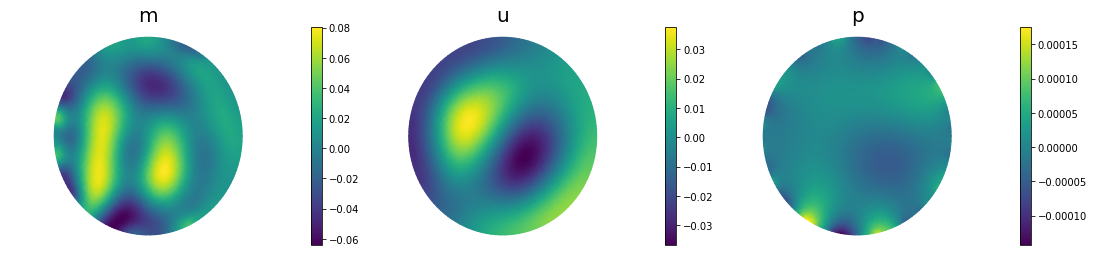

560   1.65220e-06   9.03978e-07   7.48219e-07   7.36678e-05   1.86727e-01     0
570   1.64515e-06   8.96621e-07   7.48529e-07   1.64196e-04   8.41219e-02     2
580   1.63849e-06   8.89657e-07   7.48834e-07   9.96916e-05   1.51590e-01     0
590   1.63291e-06   8.83802e-07   7.49110e-07   1.82008e-04   1.36585e-01     1
600   1.62649e-06   8.77128e-07   7.49363e-07   1.68640e-04   1.23066e-01     1


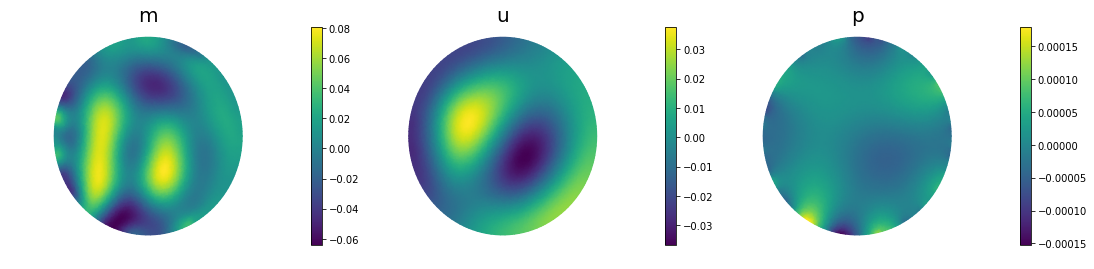

610   1.62064e-06   8.71015e-07   7.49621e-07   9.11386e-05   2.21768e-01     0
620   1.61418e-06   8.64320e-07   7.49862e-07   1.33600e-04   9.99084e-02     1
630   1.60873e-06   8.58607e-07   7.50127e-07   1.17437e-04   1.80038e-01     0
640   1.60321e-06   8.52871e-07   7.50342e-07   1.18159e-04   1.62217e-01     0
650   1.59848e-06   8.47915e-07   7.50561e-07   1.79952e-04   1.46161e-01     1


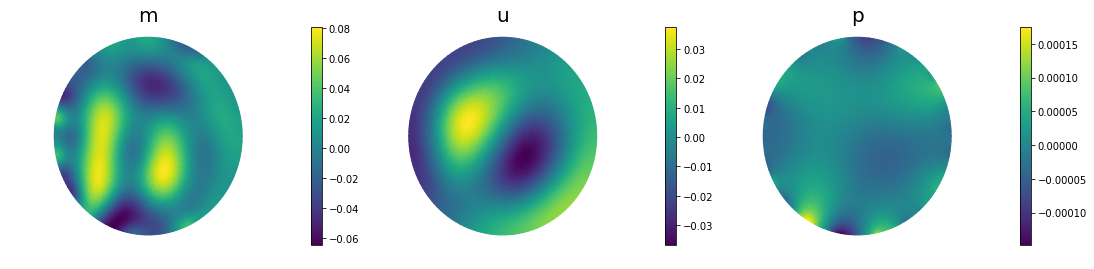

660   1.59281e-06   8.42046e-07   7.50761e-07   1.59227e-04   1.31693e-01     1
670   1.58714e-06   8.36168e-07   7.50968e-07   1.32615e-04   1.18658e-01     1
680   1.58229e-06   8.31133e-07   7.51153e-07   1.35411e-04   1.06912e-01     1
690   1.57778e-06   8.26438e-07   7.51338e-07   8.46748e-05   1.92660e-01     0
700   1.57314e-06   8.21634e-07   7.51508e-07   8.37651e-05   1.73589e-01     0


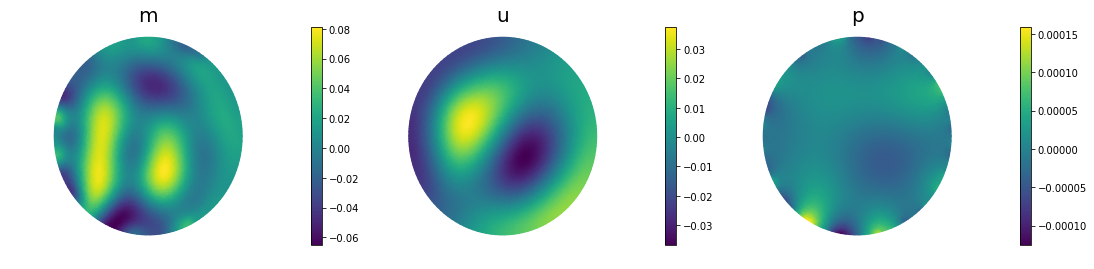

710   1.56860e-06   8.16921e-07   7.51681e-07   1.00643e-04   1.56407e-01     1
720   1.56409e-06   8.12227e-07   7.51858e-07   7.12058e-05   2.81850e-01     0
730   1.55932e-06   8.07318e-07   7.52002e-07   6.58236e-05   1.26976e-01     0
740   1.55496e-06   8.02780e-07   7.52177e-07   7.62621e-05   2.28815e-01     0
750   1.55016e-06   7.97833e-07   7.52323e-07   1.14520e-04   1.03083e-01     2


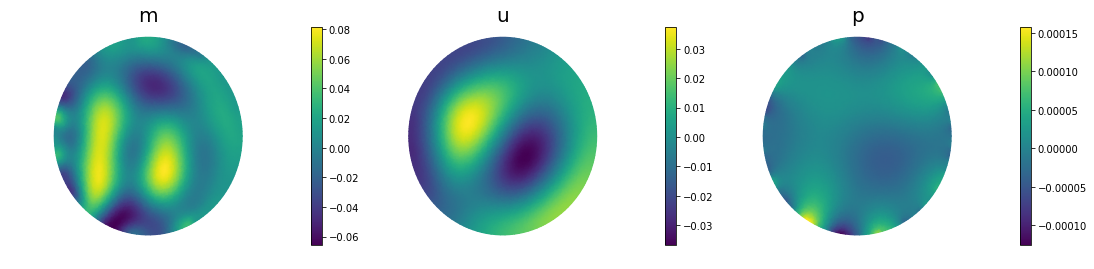

760   1.54622e-06   7.93766e-07   7.52452e-07   1.11470e-04   9.28793e-02     1
770   1.54220e-06   7.89615e-07   7.52583e-07   1.38386e-04   8.36857e-02     2
780   1.53825e-06   7.85537e-07   7.52712e-07   7.43114e-05   1.50804e-01     0
790   1.53476e-06   7.81933e-07   7.52828e-07   1.18475e-04   1.35877e-01     1
800   1.53107e-06   7.78135e-07   7.52932e-07   1.12837e-04   1.22428e-01     1


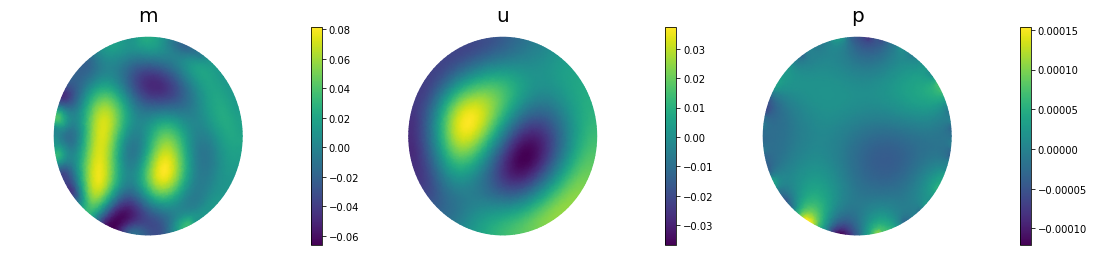

810   1.52758e-06   7.74549e-07   7.53036e-07   6.68283e-05   2.20618e-01     0
820   1.52395e-06   7.70824e-07   7.53129e-07   1.37731e-04   9.93904e-02     1
830   1.52071e-06   7.67493e-07   7.53221e-07   7.44000e-05   1.79105e-01     0
840   1.51725e-06   7.63933e-07   7.53313e-07   9.60290e-05   1.61376e-01     0
850   1.51415e-06   7.60759e-07   7.53393e-07   1.29675e-04   1.45403e-01     1


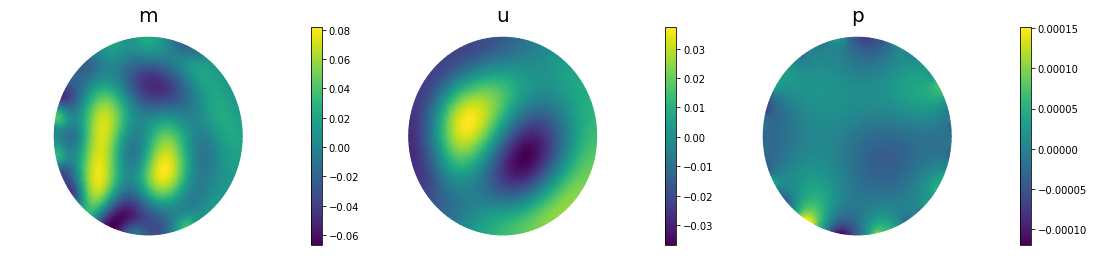

860   1.51065e-06   7.57185e-07   7.53462e-07   1.02059e-04   1.31010e-01     1
870   1.50746e-06   7.53933e-07   7.53531e-07   1.23424e-04   1.18042e-01     1
880   1.50437e-06   7.50783e-07   7.53590e-07   1.11898e-04   1.06358e-01     1
890   1.50128e-06   7.47632e-07   7.53647e-07   5.23015e-05   1.91661e-01     0
900   1.49802e-06   7.44314e-07   7.53702e-07   1.24873e-04   8.63447e-02     2


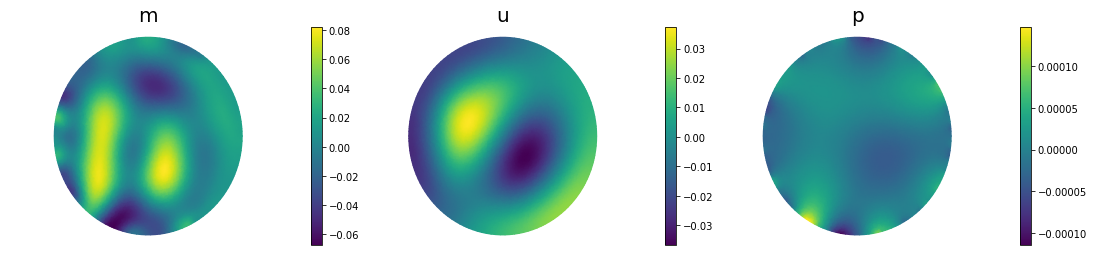

910   1.49495e-06   7.41197e-07   7.53752e-07   6.97846e-05   1.55596e-01     0
920   1.49209e-06   7.38298e-07   7.53790e-07   5.60150e-05   1.40194e-01     0
930   1.48936e-06   7.35532e-07   7.53823e-07   7.14333e-05   1.26317e-01     1
940   1.48689e-06   7.33036e-07   7.53854e-07   6.47307e-05   2.27628e-01     0
950   1.48372e-06   7.29841e-07   7.53877e-07   8.75861e-05   1.02548e-01     2


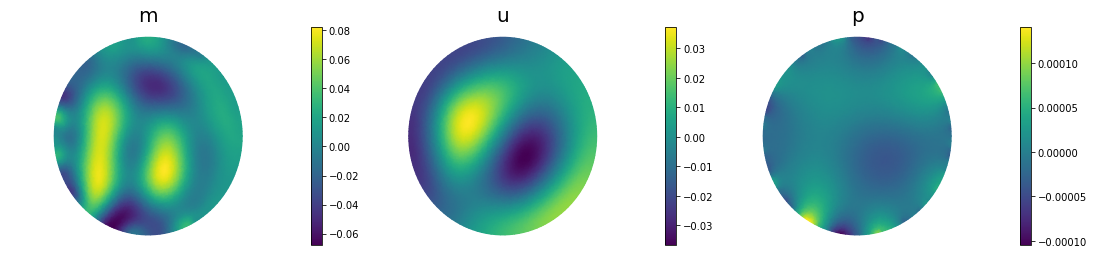

960   1.48109e-06   7.27193e-07   7.53895e-07   5.71496e-05   1.84795e-01     0
970   1.47846e-06   7.24554e-07   7.53908e-07   5.71670e-05   1.66504e-01     0
980   1.47600e-06   7.22084e-07   7.53914e-07   5.18010e-05   1.50022e-01     0
990   1.47349e-06   7.19571e-07   7.53917e-07   9.85576e-05   1.35173e-01     1
Steepest descent did not converge in  1000  iterations


In [14]:
# define parameters for the optimization
tol = 1e-4         # Relative tolerance on the gradient norm
maxiter = 1000     # Maximum number of iterations (we need a lot!)
print_any = 10     # We will only print progress on screen every few iterations
plot_any = 50      # We will plot the current solution every few iterations
c_armijo = 1e-3    # The Armijo constant to ensure sufficient descent
alpha = 1.       # The initial step-size

# initialize iter counters
iter = 0
converged = False

# initializations
g = dl.Vector()
M.init_vector(g,0)

m_prev = dl.Function(Vm)

#Select whether to use the L^2 inner product (mass matrix M)
# or to precondition steepest descent using the H^1 inner product (stiffness matrix K)
P = M
# P = K

print( "Nit  cost          misfit        reg         ||grad||       alpha  N backtrack" )

while iter <  maxiter and not converged:

    # solve the adoint problem
    adj_A, adjoint_RHS = dl.assemble_system(ufl.lhs(adjoint_eq), ufl.rhs(adjoint_eq), bc_adj)
    dl.solve(adj_A, p.vector(), adjoint_RHS)
    assert np.all(np.isfinite(p.vector().get_local())), "State solution contains NaNs"

    # Debug - print norms of state and adjoint
#     print("State norm:", u.vector().norm("l2"))
#     print("Adjoint norm:", p.vector().norm("l2"))    
    
    # evaluate the  gradient
    MG = dl.assemble(grad_misfit + grad_reg)
    dl.solve(P, g, MG)
    assert np.all(np.isfinite(g.get_local())), "State solution contains NaNs"

    # calculate the norm of the gradient
    grad_norm2 = g.inner(MG)
    gradnorm = np.sqrt(grad_norm2)
    
    if iter == 0:
        gradnorm0 = gradnorm

    # linesearch
    it_backtrack = 0
    m_prev.assign(m)
    
#     print("==== Iteration", iter, "====")
#     print("Cost_old:", cost_old)
#     print("Grad_norm2:", grad_norm2)
#     print("Alpha (before line search):", alpha)    
    
    backtrack_converged = False
    for it_backtrack in range(20):
        m.vector().axpy(-alpha, g )

        # solve the forward problem
        state_A, state_b = dl.assemble_system (ufl.lhs(forward_eq), ufl.rhs(forward_eq), bc_state)
        dl.solve(state_A, u.vector(), state_b)
        assert np.all(np.isfinite(u.vector().get_local())), "State solution contains NaNs"

        # evaluate cost
        [cost_new, misfit_new, reg_new] = cost(u, d, m, gamma)

#         print(f"Backtrack {it_backtrack}: cost_new = {cost_new}, expected ≤ {cost_old - alpha * c_armijo * grad_norm2}")

        # check if Armijo conditions are satisfied
        if cost_new < cost_old - alpha * c_armijo * grad_norm2:
            cost_old = cost_new
            backtrack_converged = True
            break
        else:
            alpha *= 0.5
            m.assign(m_prev)  # reset m
            
    if backtrack_converged == False:
        print( "Backtracking failed. A sufficient descent direction was not found" )
        converged = False
        break

    sp = ""
    if (iter % print_any)== 0 :
        print( "%3d %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %8.5e %1s %3d" % \
            (iter, sp, cost_new, sp, misfit_new, sp, reg_new, sp, \
            gradnorm, sp, alpha, sp, it_backtrack) )

    if (iter % plot_any)== 0 :
        nb.multi1_plot([m,u,p], ["m","u","p"], same_colorbar=False)
        plt.show()
    
    # check for convergence
    if gradnorm < tol*gradnorm0 and iter > 0:
        converged = True
        print ("Steepest descent converged in ",iter,"  iterations")
    
    alpha *= 1.5    # Try to increase the step size for the next iteration
    iter += 1
    
if not converged:
    print ( "Steepest descent did not converge in ", maxiter, " iterations")

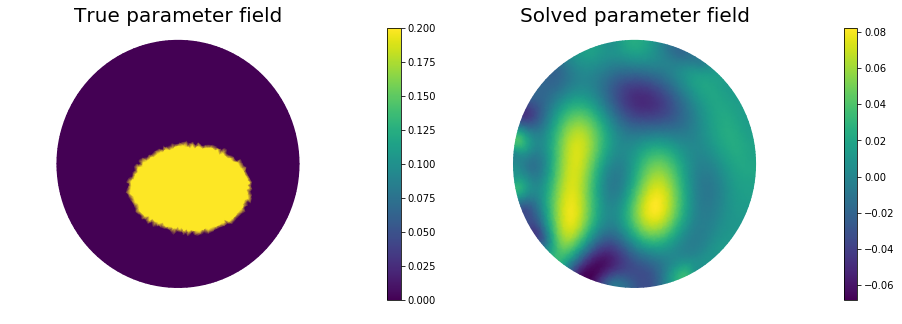

In [15]:
# plot
plt.figure(figsize=(15,5))
nb.plot(mtrue, subplot_loc=121, mytitle="True parameter field")
nb.plot(m, subplot_loc=122, mytitle="Solved parameter field")
plt.show()

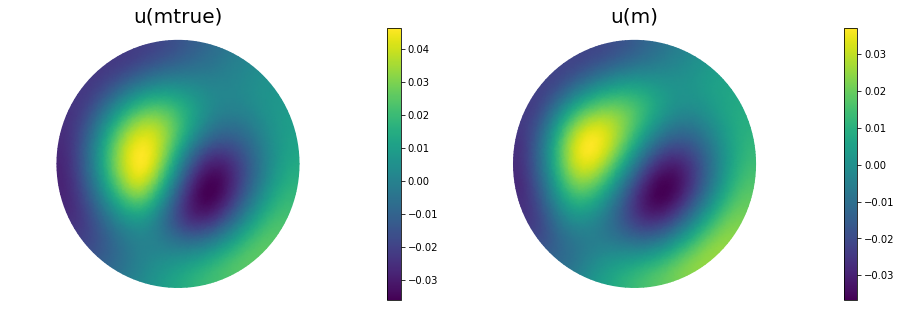

In [16]:
# plot
plt.figure(figsize=(15,5))
nb.plot(utrue, subplot_loc=121, mytitle="u(mtrue)")
nb.plot(u, subplot_loc=122, mytitle="u(m)")
plt.show()